# Dataset

In [1]:
import ast
import io
import json
import tokenize

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from datasets import Dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.sparse import hstack, csr_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
file_path = hf_hub_download(
    repo_id="OSS-forge/HumanVsAICode",
    filename="python_dataset.jsonl",
    repo_type="dataset"
)

print("File downloaded to:", file_path)

File downloaded to: /root/.cache/huggingface/hub/datasets--OSS-forge--HumanVsAICode/snapshots/03cac5dd2096c8901cb7a74e2ecbd26624ada497/python_dataset.jsonl


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

In [5]:
data[0]

{'hm_index': 'gp223799',
 'docstring': 'Sets the values to be returned after the action finishes',
 'human_code': "def action_set(values):\n    cmd = ['action-set']\n    for k, v in list(values.items()):\n        cmd.append('{}={}'.format(k, v))\n    subprocess.check_call(cmd)",
 'chatgpt_code': 'def set_return_values(values):\n    # Code to process the received values goes here\n    return values\n',
 'dsc_code': 'def action_set(values):\n    """Sets the values to be returned after the action finishes"""\n    # Assuming values is a list of values\n    for value in values:\n        # Do something with the value\n        print(value)\n\n# Call the function\naction_set([1, 2, 3, 4, 5])',
 'qwen_code': 'def action_set(values):\n    return values\n\ndef action_get():\n    """Returns the values set by action_set"""\n    return action_set([])'}

In [6]:
df = pd.DataFrame(data)

code_cols = ['human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
df_long = df.melt(id_vars=['docstring'], value_vars=code_cols,
                  var_name='writer_type', value_name='code')

df_long['writer'] = df_long['writer_type'].map({
    'human_code': 'human',
    'chatgpt_code': 'gpt',
    'dsc_code': 'dsc',
    'qwen_code': 'qwen'
})
df_long['is_ai'] = (df_long['writer'] != 'human').astype(int)

data_df = df_long[['docstring', 'code', 'writer', 'is_ai']]

In [7]:
data_df["writer"].value_counts()


,count
writer,
human,285249
gpt,285249
dsc,285249
qwen,285249


In [8]:
human_count = len(data_df[data_df["writer"] == "human"])

ai_models = ["gpt", "dsc", "qwen"]
min_ai_count = min(len(data_df[data_df["writer"] == m]) for m in ai_models)

max_ai_total = min(human_count, min_ai_count * 3)

n_per_ai_model = max_ai_total // 3
n_human = max_ai_total


In [9]:
balanced_df = pd.concat([
    data_df[data_df["writer"] == "human"].sample(n=n_human, random_state=42),

    data_df[data_df["writer"] == "gpt"].sample(n=n_per_ai_model, random_state=42),
    data_df[data_df["writer"] == "dsc"].sample(n=n_per_ai_model, random_state=42),
    data_df[data_df["writer"] == "qwen"].sample(n=n_per_ai_model, random_state=42),
])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [10]:
balanced_df["writer"].value_counts()

,count
writer,
human,285249
dsc,95083
gpt,95083
qwen,95083


In [11]:
print(balanced_df["writer"].value_counts())
print(balanced_df["is_ai"].value_counts())


writer
human    285249
dsc       95083
gpt       95083
qwen      95083
Name: count, dtype: int64
is_ai
0    285249
1    285249
Name: count, dtype: int64


In [12]:
data_df

,docstring,code,writer,is_ai
0,Sets the values to be returned after the actio...,def action_set(values):\n cmd = ['action-se...,human,0
1,Return text for index entry based on object type.,"def get_index_text(self, modname, name_cls):\n...",human,0
2,"Parse a slice string, of the same form as used...","def parse(v):\n parts = v.split(',')\n ...",human,0
3,Newton power flow routine\n\n Returns\n...,def newton(self):\n dae = self.system.d...,human,0
4,Filter the feed based on self.buffer_distance_...,def _filter_spatially(self):\n if self....,human,0
...,...,...,...,...
1140991,Retrieve the IDs of all obstorys.\n\n :...,def get_obstory_ids(self):\n return self._o...,qwen,1
1140992,Download a url to bytes.\n\n if chunk_size ...,"def download_to_bytes(url, chunk_size=1024 * 1...",qwen,1
1140993,Return a class name (string) if the current UR...,"def current(context, urlName, className='activ...",qwen,1
1140994,Stem a French word and return the stemmed form...,"def stem(self, word):\n pass",qwen,1


In [13]:
dataset = Dataset.from_pandas(balanced_df)

In [14]:
dataset

Dataset({
    features: ['docstring', 'code', 'writer', 'is_ai'],
    num_rows: 570498
})

In [15]:
dataset[0]

{'docstring': 'Create specified hunt.\n\n    Args:\n      name: string containing hunt name.\n      args: proto (*FlowArgs) for type of hunt, as defined in GRR flow proto.\n\n    Returns:\n      The newly created GRR hunt object.\n\n    Raises:\n      ValueError: if approval is needed and approvers were not specified.',
 'code': "def _create_hunt(self, name, args):\n    runner_args = self.grr_api.types.CreateHuntRunnerArgs()\n    runner_args.description = self.reason\n    hunt = self.grr_api.CreateHunt(\n        flow_name=name, flow_args=args, hunt_runner_args=runner_args)\n    print('{0!s}: Hunt created'.format(hunt.hunt_id))\n    self._check_approval_wrapper(hunt, hunt.Start)\n    return hunt",
 'writer': 'human',
 'is_ai': 0}

In [16]:
split1 = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split1['train']
temp_dataset = split1['test']

split2 = temp_dataset.train_test_split(test_size=0.5, seed=42)
val_dataset = split2['train']
test_dataset = split2['test']

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 456398
Validation size: 57050
Test size: 57050


# Feature Extraction

### Abstract Syntax Tree Feature Extraction

Created a feature extractor that uses abstract syntax trees to find structural characteristics of Python code. ASTs represent the syntactic structure of the program as a hierarchical tree allowing you to analyze independent of formatting and whitespace. From this representation we extracted features in 5 main categories: control flow, error_handling, structure, identifier, comment.

In [17]:
class ASTFeatureExtractor(ast.NodeVisitor):

  def __init__(self):

    self.FEATURE_NAMES = [

      'if',
      'for',
      'while',
      'return',
      'break',
      'continue',

      'error_handling',

      'functions',
      'classes',
      'docstrings',

      'unique_identifiers',
      'avg_identifier_length',
      'single_char_identifiers',

      'comment_count',
      'avg_comment_length',
      'comment_density',
      'todo_comments',

      'max_depth'

    ]

    self.features = {

      'if': 0,
      'for': 0,
      'while': 0,
      'return': 0,
      'break': 0,
      'continue': 0,
      'error_handling': 0,
      'functions': 0,
      'classes': 0,
      'docstrings': 0
    }

    self.identifiers = []

    self.curr_depth = 0
    self.max_depth = 0

    self.comment_count = 0
    self.comment_lengths = []
    self.todo_comments = 0

    self.total_lines = 0


  def generic_visit(self, node):
    self.curr_depth += 1
    self.max_depth = max(self.max_depth, self.curr_depth)
    super().generic_visit(node)
    self.curr_depth -= 1


  #control flow
  def visit_If(self, node):
    self.features["if"] += 1
    super().generic_visit(node)

  def visit_For(self, node):
    self.features["for"] += 1
    super().generic_visit(node)

  def visit_While(self, node):
    self.features["while"] += 1
    super().generic_visit(node)

  def visit_Return(self, node):
    self.features["return"] += 1
    super().generic_visit(node)

  def visit_Break(self, node):
    self.features["break"] += 1

  def visit_Continue(self, node):
    self.features["continue"] += 1

  #error handling
  def visit_Try(self, node):
    self.features["error_handling"] += 1
    super().generic_visit(node)

  def visit_Assert(self, node):
    self.features["error_handling"] += 1
    super().generic_visit(node)

  def visit_Raise(self, node):
    self.features["error_handling"] += 1
    super().generic_visit(node)

  #structure
  def visit_FunctionDef(self, node):
        self.features["functions"] += 1

        if ast.get_docstring(node):
            self.features["docstrings"] += 1

        super().generic_visit(node)

  def visit_ClassDef(self, node):
      self.features["classes"] += 1

      if ast.get_docstring(node):
          self.features["docstrings"] += 1

      super().generic_visit(node)

  def extract_comments(self, source_code):
      self.comment_count = 0
      self.comment_lengths = []
      self.todo_comments = 0

      tokens = tokenize.generate_tokens(io.StringIO(source_code).readline)

      for tok_type, tok_string, _, _, _ in tokens:
          if tok_type == tokenize.COMMENT:
              self.comment_count += 1

              cleaned = tok_string.lstrip("#").strip()
              self.comment_lengths.append(len(cleaned))

              if "todo" in cleaned.lower() or "fixme" in cleaned.lower():
                  self.todo_comments += 1

  #identifiers
  def visit_Name(self, node):
    self.identifiers.append(node.id)
    super().generic_visit(node)

  #feature vector
  def get_feature_vector(self):

    if self.identifiers:
      unique_identifiers = len(set(self.identifiers))
      identifier_lengths = [len(identifier) for identifier in set(self.identifiers)]
      avg_identifier_length = round(sum(identifier_lengths) / len(identifier_lengths) if len(identifier_lengths) > 0 else 0, 2)
      single_char_identifiers = sum(1 for name in self.identifiers if len(name) == 1)
    else:
      unique_identifiers = 0
      avg_identifier_length = 0
      single_char_identifiers = 0

    if self.comment_lengths:
            avg_comment_length = round(
                sum(self.comment_lengths) / len(self.comment_lengths),
                2
            )
    else:
            avg_comment_length = 0

    comment_density = round(
          self.comment_count / self.total_lines,
          4
      ) if self.total_lines > 0 else 0

    self.features["unique_identifiers"] = unique_identifiers
    self.features["avg_identifier_length"] = avg_identifier_length
    self.features["single_char_identifiers"] = single_char_identifiers
    self.features["comment_count"] = self.comment_count
    self.features["avg_comment_length"] = avg_comment_length
    self.features["comment_density"] = comment_density
    self.features["todo_comments"] = self.todo_comments
    self.features["max_depth"] = self.max_depth

    return [self.features.get(f, 0) for f in self.FEATURE_NAMES]

  def get_zero_vector(self):
        return [0.0] * len(self.FEATURE_NAMES)


  def extract(self, source_code):
        self.total_lines = len(source_code.splitlines())

        try:
            tree = ast.parse(source_code)
            self.visit(tree)
        except SyntaxError:
            return self.get_zero_vector()

        self.extract_comments(source_code)

        return self.get_feature_vector()


Feature Extractor Testing

In [18]:
dataset[0]['code']

"def _create_hunt(self, name, args):\n    runner_args = self.grr_api.types.CreateHuntRunnerArgs()\n    runner_args.description = self.reason\n    hunt = self.grr_api.CreateHunt(\n        flow_name=name, flow_args=args, hunt_runner_args=runner_args)\n    print('{0!s}: Hunt created'.format(hunt.hunt_id))\n    self._check_approval_wrapper(hunt, hunt.Start)\n    return hunt"

In [19]:
ASTFeatureExtractor().extract(dataset[0]['code'])

[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 6, 5.33, 0, 0, 0, 0.0, 0, 7]

In [20]:
test_set = dataset[:10]
test_features = np.array([ASTFeatureExtractor().extract(code) for code in test_set['code']], dtype=np.float32)
test_features

array([[ 0.    ,  0.    ,  0.    ,  1.    ,  0.    ,  0.    ,  0.    ,
         1.    ,  0.    ,  0.    ,  6.    ,  5.33  ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  7.    ],
       [ 1.    ,  0.    ,  0.    ,  2.    ,  0.    ,  0.    ,  0.    ,
         1.    ,  0.    ,  0.    ,  4.    ,  4.25  ,  0.    ,  6.    ,
        25.5   ,  0.2609,  0.    ,  5.    ],
       [ 0.    ,  0.    ,  0.    ,  1.    ,  0.    ,  0.    ,  0.    ,
         1.    ,  0.    ,  0.    ,  3.    ,  7.33  ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  5.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  1.    ],
       [ 1.    ,  1.    ,  0.    ,  1.    ,  0.    ,  0.    ,  0.    ,
         1.    ,  0.    ,  0.    , 15.    , 10.27  ,  0.    ,  5.    ,
        51.2   ,  0.1163,  0.    ,  5.    ],
       [ 3.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  1.

### Term Frequency - Inverse Document Frequency (TF-IDF) Feature Extraction

Combined two different TF-IDF vectorizers to obtain two complementary sets of lexical features: a token-level TF-IDF representation and a character-level 4-gram TF-IDF representation. The token-based features captures identifiers and keywords while the character-4-gram featyres captures stylistic patterns within identifiers or patterns across tokens.

In [21]:
class TFIDFExtractor:

    def __init__(self, max_token_features=5000, max_char_features=5000):

        self.token_vectorizer = TfidfVectorizer(
            token_pattern=r'\b\w+\b',
            max_features=max_token_features
        )

        self.char_vectorizer = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(4, 4),
            max_features=max_char_features
        )

    def fit(self, code_list):

        self.token_vectorizer.fit(code_list)
        self.char_vectorizer.fit(code_list)
        return self

    def transform(self, code_list):

        token_features = self.token_vectorizer.transform(code_list)
        char_features = self.char_vectorizer.transform(code_list)

        return hstack([token_features, char_features])

    def get_feature_names(self):

        token_names = self.token_vectorizer.get_feature_names_out()
        char_names = self.char_vectorizer.get_feature_names_out()

        token_names = [f"tok_{t}" for t in token_names]
        char_names = [f"char_{c}" for c in char_names]

        return np.concatenate([token_names, char_names])

### Data Processing

Fit TF-IDF Extractor

These vectorizers find thousands of tokens many of which only appear a few times in the entire dataset of code and contribute very little useful information. To reduce the dimensionality of the feature space and limit memory usage, we cut down to the top 400 (200 token and 200 character-4-gram).

In [22]:
tfidf_extractor = TFIDFExtractor(max_token_features=200, max_char_features=200)
tfidf_extractor.fit(train_dataset['code'])

Transform data using fitted extractor

In [23]:
X_train_tfidf = tfidf_extractor.transform(train_dataset["code"])
X_val_tfidf   = tfidf_extractor.transform(val_dataset["code"])

In [24]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

Compute AST features

In [25]:
X_train_ast = np.array([
    ASTFeatureExtractor().extract(code)
    for code in train_dataset["code"]
], dtype=np.float32)

X_val_ast = np.array([
    ASTFeatureExtractor().extract(code)
    for code in val_dataset["code"]
], dtype=np.float32)

Combine TF-IDF and AST into single unified feature vector per sample

In [26]:
X_train = hstack([
    X_train_tfidf,
    csr_matrix(X_train_ast)
])

X_val = hstack([
    X_val_tfidf,
    csr_matrix(X_val_ast)
])

In [27]:
print(X_train_ast.shape)
print(X_train_tfidf.shape)

(456398, 18)
(456398, 400)


In [28]:
print(X_train.shape)
print(X_val.shape)

(456398, 418)
(57050, 418)


In [29]:
y_train = np.array(train_dataset["is_ai"])
y_val = np.array(val_dataset["is_ai"])

In [30]:
print(y_train.shape)
print(y_val.shape)

(456398,)
(57050,)


# Logistic Regression

Scale vectors and then train model

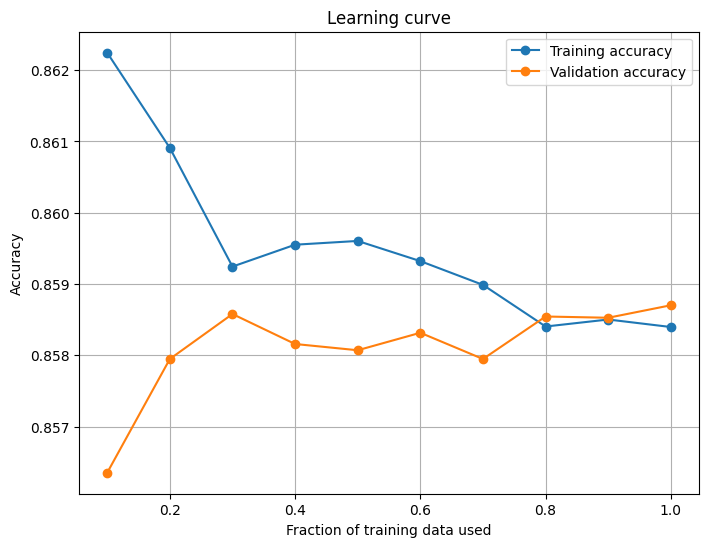

In [31]:
fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

train_acc = []
val_acc = []

scaler = StandardScaler(with_mean = False)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

clf = LogisticRegression(max_iter=2000, solver='saga', n_jobs=-1, tol=1e-3)

for frac in fractions:
    n_samples = int(X_train_scaled.shape[0] * frac)
    X_subset = X_train_scaled[:n_samples]
    y_subset = y_train[:n_samples]

    clf.fit(X_subset, y_subset)

    # Training accuracy
    y_train_pred = clf.predict(X_subset)
    train_acc.append(accuracy_score(y_subset, y_train_pred))

    # Validation accuracy
    y_val_pred = clf.predict(X_val_scaled)
    val_acc.append(accuracy_score(y_val, y_val_pred))


# Learning curve
plt.figure(figsize=(8,6))
plt.plot(fractions, train_acc, 'o-', label='Training accuracy')
plt.plot(fractions, val_acc, 'o-', label='Validation accuracy')
plt.xlabel('Fraction of training data used')
plt.ylabel('Accuracy')
plt.title('Learning curve')
plt.legend()
plt.grid(True)
plt.show()



# Evaluation

Process test data using same steps as training data.

1.   Compute TF-IDF and AST features
2.   Combine them
3.   Scale them



In [32]:
X_test_tfidf = tfidf_extractor.transform(test_dataset["code"])

X_test_ast = np.array([
    ASTFeatureExtractor().extract(code)
    for code in test_dataset["code"]
], dtype=np.float32)

X_test = hstack([
    X_test_tfidf,
    csr_matrix(X_test_ast)
])

X_test_scaled = scaler.transform(X_test)

Accuracy and ROC metrics

In [33]:
y_test = np.array(test_dataset["is_ai"])
y_test_pred = clf.predict(X_test_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_test_pred)}')

y_test_proba = clf.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_test_proba)
print(f"AUROC: {auroc:.4f}")


Accuracy: 0.8576336546888694
AUROC: 0.6416


Analyze Mislabelled Data

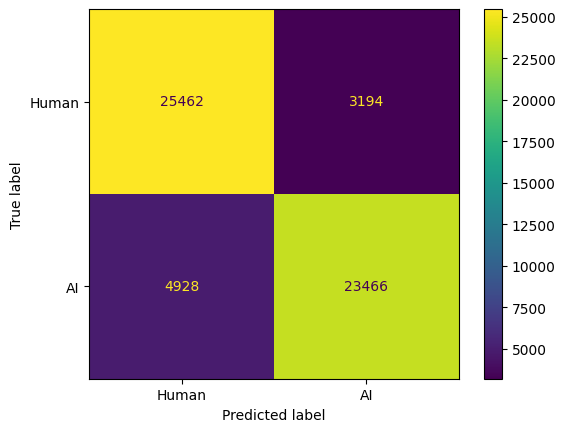

In [34]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"])
disp.plot()

In [35]:
eval_df = pd.DataFrame({
    "true_label": y_test,
    "pred_label": y_test_pred,
    "writer": test_dataset["writer"]
})

eval_df["incorrect"] = eval_df["true_label"] != eval_df["pred_label"]

human_df = eval_df[eval_df["writer"] == "human"]
human_mislabel_pct = human_df["incorrect"].mean() * 100

ai_df = eval_df[eval_df["writer"] != "human"]
ai_mislabel_pct = ai_df["incorrect"].mean() * 100

model_mislabel_pct = (
    ai_df
    .groupby("writer")["incorrect"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(f"Human mislabeled: {human_mislabel_pct:.2f}%")
print(f"AI mislabeled (overall): {ai_mislabel_pct:.2f}%\n")

print("AI mislabeled by model:")
for model, pct in model_mislabel_pct.items():
    print(f"{model}: {pct:.2f}%")


Human mislabeled: 11.15%
AI mislabeled (overall): 17.36%

AI mislabeled by model:
qwen: 30.20%
gpt: 16.61%
dsc: 5.44%


Analyze Feature Weights

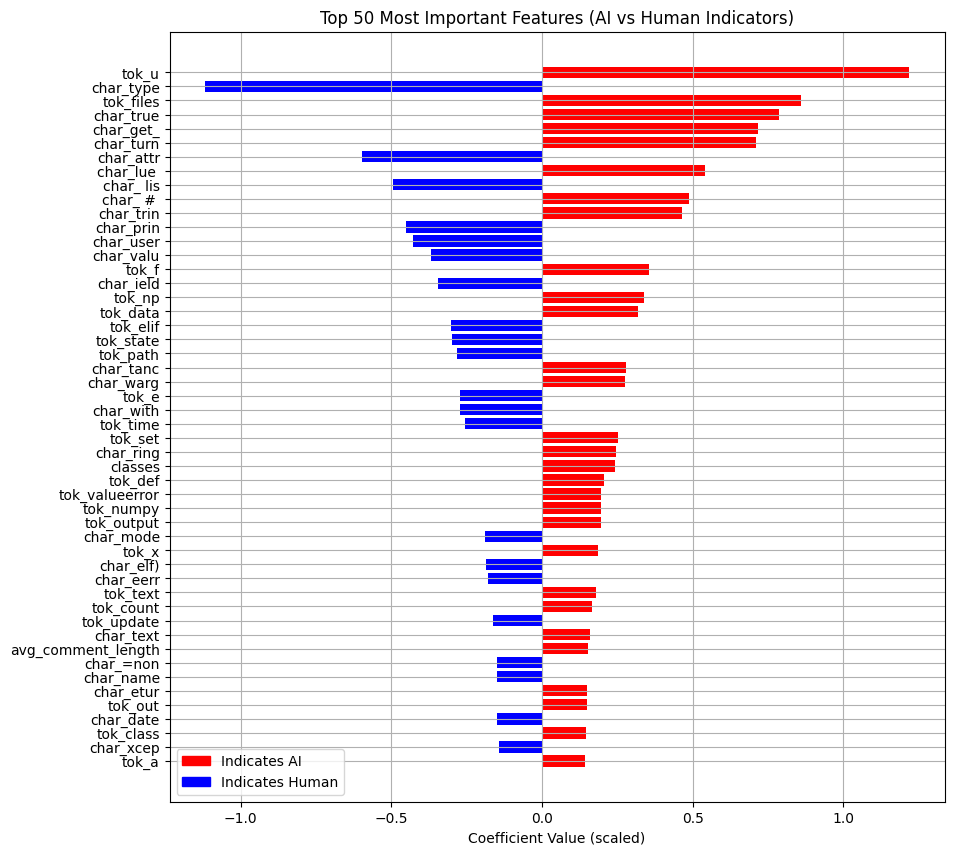

In [36]:
ast_feature_names = ASTFeatureExtractor().FEATURE_NAMES
tfidf_feature_names = tfidf_extractor.get_feature_names()

feature_names = np.concatenate([
    ast_feature_names,
    tfidf_feature_names
])

coefficients = clf.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_importance": np.abs(coefficients)
}).sort_values(by="abs_importance", ascending=False)

top_features = importance_df.head(50).copy()

top_features["direction"] = np.where(
    top_features["coefficient"] > 0,
    "AI",
    "Human"
)

colors = top_features["direction"].map({
    "AI": "red",
    "Human": "blue"
})


plt.figure(figsize=(10,10))

plt.barh(
    top_features["feature"][::-1],
    top_features["coefficient"][::-1],
    color=colors[::-1]
)

plt.xlabel("Coefficient Value (scaled)")
plt.title("Top 50 Most Important Features (AI vs Human Indicators)")
plt.grid(True)

import matplotlib.patches as mpatches
ai_patch = mpatches.Patch(color="red", label="Indicates AI")
human_patch = mpatches.Patch(color="blue", label="Indicates Human")

plt.legend(handles=[ai_patch, human_patch])

plt.show()

Test on new dataset

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
csv_path = "/content/drive/MyDrive/AI-Human-Generated-Program-Code-Dataset(1).csv"
github_df = pd.read_csv(csv_path)


In [39]:
github_df

,id,problem_number,language,difficulty,generator_name,generator_type,description,prompt,ai_generated_code,human_generated_code
0,1,1,Java,easy,Bing AI Chat,Chatbot,You are given a 0-indexed integer array nums. ...,solve the following problem with java code. Cl...,public class Solution {\n public int maxSum...,class Solution {\n public int maxSum(int[] ...
1,2,1,Python,easy,Bing AI Chat,Chatbot,You are given a 0-indexed integer array nums. ...,solve the following problem with python3 code....,"class Solution:\n def maxSum(self, nums: Li...","class Solution:\n def maxSum(self, nums: Li..."
2,3,1,C++,easy,Bing AI Chat,Chatbot,You are given a 0-indexed integer array nums. ...,solve the following problem with C++ code. Cla...,class Solution {\npublic:\n int maxSum(std:...,class Solution {\n public:\n int max...
3,4,2,Java,easy,Bing AI Chat,Chatbot,"Your laptop keyboard is faulty, and whenever y...",Solve the following problem with java code. Cl...,class Solution {\n public String finalStrin...,class Solution {\n public String finalStrin...
4,5,2,Python,easy,Bing AI Chat,Chatbot,"Your laptop keyboard is faulty, and whenever y...",Solve the following problem with python3 code....,"class Solution:\n def finalString(self, s: ...","class Solution:\n def finalString(self, s: ..."
...,...,...,...,...,...,...,...,...,...,...
85,86,5,Python,hard,GitHub Copilot,IDE Extension,You are given an array nums of n positive inte...,"class Solution:\n def maximumScore(self, nu...","class Solution:\n def maximumScore(self, nu...",class Solution: \n MOD = 1000000007\n\n ...
86,87,5,C++,hard,GitHub Copilot,IDE Extension,You are given an array nums of n positive inte...,class Solution {\npublic:\n int maximumScor...,class Solution {\npublic:\n int maximumScor...,class Solution {\npublic:\n const int MOD =...
87,88,6,Java,hard,GitHub Copilot,IDE Extension,You are given a 0-indexed 2D integer array ite...,public class Solution {\n public int findMa...,public class Solution {\n public int findMa...,class Solution {\n public long findMaximumE...
88,89,6,Python,hard,GitHub Copilot,IDE Extension,You are given a 0-indexed 2D integer array ite...,class Solution:\n def findMaximumElegance(s...,class Solution:\n def findMaximumElegance(s...,class Solution:\n def findMaximumElegance(s...


In [40]:
python_df = github_df[github_df["language"] == "Python"]


In [41]:
python_df

,id,problem_number,language,difficulty,generator_name,generator_type,description,prompt,ai_generated_code,human_generated_code
1,2,1,Python,easy,Bing AI Chat,Chatbot,You are given a 0-indexed integer array nums. ...,solve the following problem with python3 code....,"class Solution:\n def maxSum(self, nums: Li...","class Solution:\n def maxSum(self, nums: Li..."
4,5,2,Python,easy,Bing AI Chat,Chatbot,"Your laptop keyboard is faulty, and whenever y...",Solve the following problem with python3 code....,"class Solution:\n def finalString(self, s: ...","class Solution:\n def finalString(self, s: ..."
7,8,3,Python,medium,Bing AI Chat,Chatbot,You are given a 0-indexed integer array nums a...,Solve the following problem with python3 code....,class Solution:\n def minAbsoluteDifference...,class Solution:\n def minAbsoluteDifference(s...
10,11,4,Python,medium,Bing AI Chat,Chatbot,You are given the head of a non-empty linked l...,Solve the following problem with python3 code....,"class Solution:\n def doubleIt(self, head: ...","class Solution:\n def doubleIt(self, head: ..."
13,14,5,Python,hard,Bing AI Chat,Chatbot,You are given an array nums of n positive inte...,Solve the following problem with python3 code....,"class Solution:\n def maximumScore(self, nu...",class Solution: \n MOD = 1000000007\n\n ...
16,17,6,Python,hard,Bing AI Chat,Chatbot,You are given a 0-indexed 2D integer array ite...,Solve the following problem with python3 code....,class Solution:\n def findMaximumElegance(s...,class Solution:\n def findMaximumElegance(s...
19,20,1,Python,easy,ChatGPT,Chatbot,You are given a 0-indexed integer array nums. ...,solve the following problem with python3 code....,"class Solution:\n def maxSum(self, nums: Li...","class Solution:\n def maxSum(self, nums: Li..."
22,23,2,Python,easy,ChatGPT,Chatbot,"Your laptop keyboard is faulty, and whenever y...",Solve the following problem with python3 code....,"class Solution:\n def finalString(self, s: ...","class Solution:\n def finalString(self, s: ..."
25,26,3,Python,medium,ChatGPT,Chatbot,You are given a 0-indexed integer array nums a...,Solve the following problem with python3 code....,class Solution:\n def minAbsoluteDifference...,class Solution:\n def minAbsoluteDifference(s...
28,29,4,Python,medium,ChatGPT,Chatbot,You are given the head of a non-empty linked l...,Solve the following problem with python3 code....,"class Solution:\n def doubleIt(self, head: ...","class Solution:\n def doubleIt(self, head: ..."


In [42]:
ai_df = python_df[['description', 'ai_generated_code', 'generator_name']].copy()

ai_df = ai_df.rename(columns={
    'description': 'docstring',
    'ai_generated_code': 'code',
    'generator_name': 'writer'
})

ai_df['is_ai'] = 1

human_df = python_df[['description', 'human_generated_code']].copy()

human_df = human_df.rename(columns={
    'description': 'docstring',
    'human_generated_code': 'code'
})

human_df['writer'] = 'human'
human_df['is_ai'] = 0

combined_df = pd.concat([ai_df, human_df], ignore_index=True)

combined_df = combined_df[
    combined_df['code'].notna() &
    (combined_df['code'].str.strip() != "")
]

combined_df = combined_df[['docstring', 'code', 'writer', 'is_ai']]

print("Final Python samples:", len(combined_df))
print("AI ratio:", combined_df['is_ai'].mean())

Final Python samples: 60
AI ratio: 0.5


In [43]:
github_test_tfidf   = tfidf_extractor.transform(combined_df["code"])
github_test_ast = np.array([
    ASTFeatureExtractor().extract(code)
    for code in combined_df["code"]
], dtype=np.float32)
github_test = hstack([
    github_test_tfidf,
    csr_matrix(github_test_ast)
])

In [44]:
github_y_test = np.array(combined_df["is_ai"])

github_y_test_pred = clf.predict(github_test)
print(accuracy_score(github_y_test, github_y_test_pred))


0.5


In [45]:
github_eval_df = pd.DataFrame({
    "true_label": github_y_test,
    "pred_label": github_y_test_pred,
    "writer": combined_df["writer"]
})

github_eval_df["incorrect"] = github_eval_df["true_label"] != github_eval_df["pred_label"]

human_df = github_eval_df[github_eval_df["writer"] == "human"]
human_mislabel_pct = human_df["incorrect"].mean() * 100

ai_df = github_eval_df[github_eval_df["writer"] != "human"]
ai_mislabel_pct = ai_df["incorrect"].mean() * 100

model_mislabel_pct = (
    ai_df
    .groupby("writer")["incorrect"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

In [46]:
print(f"Human mislabeled: {human_mislabel_pct:.2f}%")
print(f"AI mislabeled (overall): {ai_mislabel_pct:.2f}%\n")

print("AI mislabeled by model:")
for model, pct in model_mislabel_pct.items():
    print(f"{model}: {pct:.2f}%")

Human mislabeled: 0.00%
AI mislabeled (overall): 100.00%

AI mislabeled by model:
Bing AI Chat: 100.00%
ChatGPT: 100.00%
Code Llama: 100.00%
CodeWhisperer: 100.00%
GitHub Copilot: 100.00%
